<a href="https://colab.research.google.com/github/tapasyapandiyan/Dwarka-Nexus/blob/main/dwarka_nexus_colab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Installing Qiskit and simulator tools
!pip install qiskit qiskit-aer matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.9 MB/s eta 0:00:00


✅ Saved map to dwarka_subsea_map.html


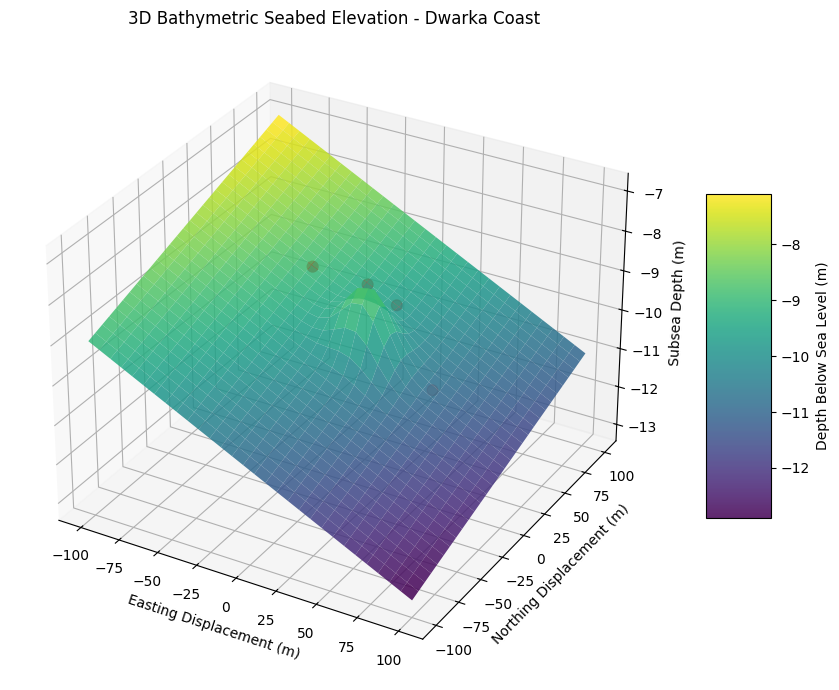

In [2]:
# Installing geospatial and plotting tools
!pip install folium geopandas matplotlib

import folium
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- SECTION 1: GEOSPATIAL MAPPING ---
# Centering the survey map directly off the coast of Samudranarayan Temple
dwarka_coords = [22.2464, 68.9642]
m = folium.Map(location=dwarka_coords, zoom_start=14, tiles="OpenStreetMap")

# Marking ground-truth excavation sites from NIO/ASI survey records
sites = [
    {"name": "Submerged Bastion A", "coords": [22.2464, 68.9642], "depth": "7.0m", "color": "red"},
    {"name": "Stone Anchor Zone B", "coords": [22.2470, 68.9650], "depth": "8.5m", "color": "blue"},
    {"name": "Foundation Wall C",   "coords": [22.2458, 68.9638], "depth": "6.8m", "color": "green"},
    {"name": "Deep Anomaly D",     "coords": [22.2481, 68.9661], "depth": "11.2m", "color": "purple"}
]

# Adding markers for each underwater node on the map
for site in sites:
    folium.Marker(
        location=site["coords"],
        popup=f"<b>{site['name']}</b><br>Depth: {site['depth']}",
        icon=folium.Icon(color=site["color"], icon="info-sign")
    ).add_to(m)

# Exporting the interactive map to HTML
m.save("dwarka_subsea_map.html")
print("✅ Saved map to dwarka_subsea_map.html")


# --- SECTION 2: 3D SEABED BATHYMETRY ---
# Generating a 2D spatial mesh grid (-100m to +100m displacement)
x = np.linspace(-100, 100, 30)
y = np.linspace(-100, 100, 30)
X, Y = np.meshgrid(x, y)

# Modeling underwater depth variations and underwater masonry ridges
Z = -10 - 0.02 * X + 0.01 * Y + 1.5 * np.exp(-((X-10)**2 + (Y-10)**2)/300)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Rendering the seabed surface mesh
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.85)

# Plotting specific anomaly targets directly onto the 3D grid
ax.scatter([10, 20, -10, 35], [10, 25, -15, 40], [-8.5, -9.2, -7.8, -11.5],
           color='red', s=60, label='Archaeological Nodes')

# Labelling spatial axes and color bar
ax.set_title("3D Bathymetric Seabed Elevation - Dwarka Coast")
ax.set_xlabel("Easting Displacement (m)")
ax.set_ylabel("Northing Displacement (m)")
ax.set_zlabel("Subsea Depth (m)")
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label="Depth Below Sea Level (m)")

plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
import json

# --- SECTION 3: EXPORTING ARCHAEOLOGICAL MATRIX DATA ---
print("=========================================================")
print("     DWARKA SUBSEA MATRIX - SPATIAL DATA EXPORT          ")
print("=========================================================")

# Structuring ground-truth sites and 3D depth parameters
export_data = [
    {"Node_ID": "Node_0", "Site": "Submerged Bastion A", "Lat": 22.2464, "Lon": 68.9642, "Depth_m": 7.0, "Priority_Rank": 1},
    {"Node_ID": "Node_1", "Site": "Stone Anchor Zone B", "Lat": 22.2470, "Lon": 68.9650, "Depth_m": 8.5, "Priority_Rank": 2},
    {"Node_ID": "Node_2", "Site": "Foundation Wall C",   "Lat": 22.2458, "Lon": 68.9638, "Depth_m": 6.8, "Priority_Rank": 1},
    {"Node_ID": "Node_3", "Site": "Deep Anomaly D",     "Lat": 22.2481, "Lon": 68.9661, "Depth_m": 11.2, "Priority_Rank": 3}
]

# Converting to DataFrame for quick inspection
df = pd.DataFrame(export_data)
print("\n[+] Structured GIS Data Table:")
print(df.to_string(index=False))

# Saving to CSV for local project storage
df.to_csv("dwarka_archeology_grid.csv", index=False)
print("\n✅ Successfully exported spatial data to 'dwarka_archeology_grid.csv'")



     DWARKA SUBSEA MATRIX - SPATIAL DATA EXPORT          

[+] Structured GIS Data Table:
Node_ID                Site     Lat     Lon  Depth_m  Priority_Rank
 Node_0 Submerged Bastion A 22.2464 68.9642      7.0              1
 Node_1 Stone Anchor Zone B 22.2470 68.9650      8.5              2
 Node_2   Foundation Wall C 22.2458 68.9638      6.8              1
 Node_3      Deep Anomaly D 22.2481 68.9661     11.2              3

✅ Successfully exported spatial data to 'dwarka_archeology_grid.csv'
